In [8]:
import torch
from torch_geometric.data import Data
import torch_geometric.nn as pyg_nn
from pipeline import *
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [2]:
binance = Binance().data

In [6]:
binance.head()

,Date,Symbol,Open,High,Low,Close,Volume DOGE,Volume USDT,tradecount
0,2023-10-19 23:00:00,DOGEUSDT,0.05865,0.05890,0.05863,0.05887,12250066.0,7.197851e+05,1872
1,2023-10-19 22:00:00,DOGEUSDT,0.05858,0.05875,0.05857,0.05865,8809389.0,5.168053e+05,1359
2,2023-10-19 21:00:00,DOGEUSDT,0.05873,0.05877,0.05855,0.05858,15152955.0,8.885734e+05,2018
3,2023-10-19 20:00:00,DOGEUSDT,0.05866,0.05899,0.05854,0.05872,27370557.0,1.607658e+06,3333
4,2023-10-19 19:00:00,DOGEUSDT,0.05852,0.05870,0.05849,0.05867,3577543.0,2.097033e+05,857


Log Return
Convert price levels into returns: log return = log(Close_t / Close_{t-1})


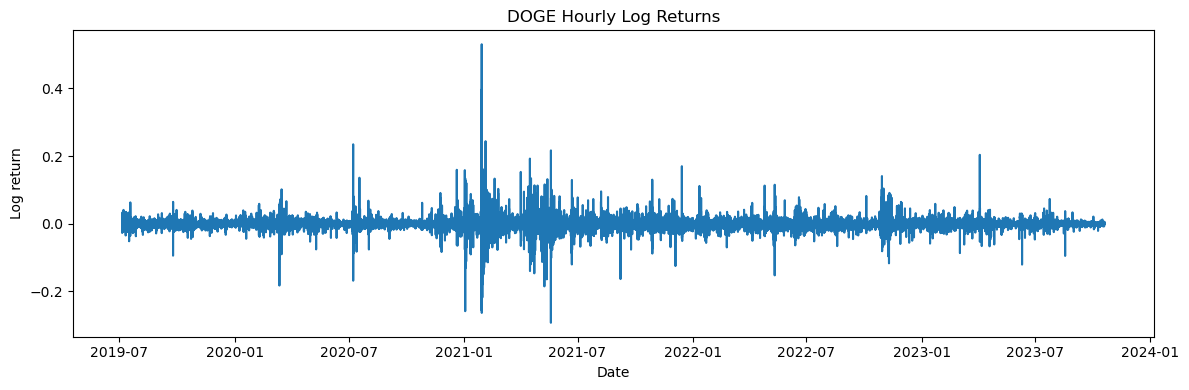

Rolling Volatility
Crypto markets exhibit strong volatility dynamics, with periods of calm followed by bursts of high volatility. Rolling volatility helps us visualize these changes over time.
rolling volatility of 24h and 7d (std of log returns)


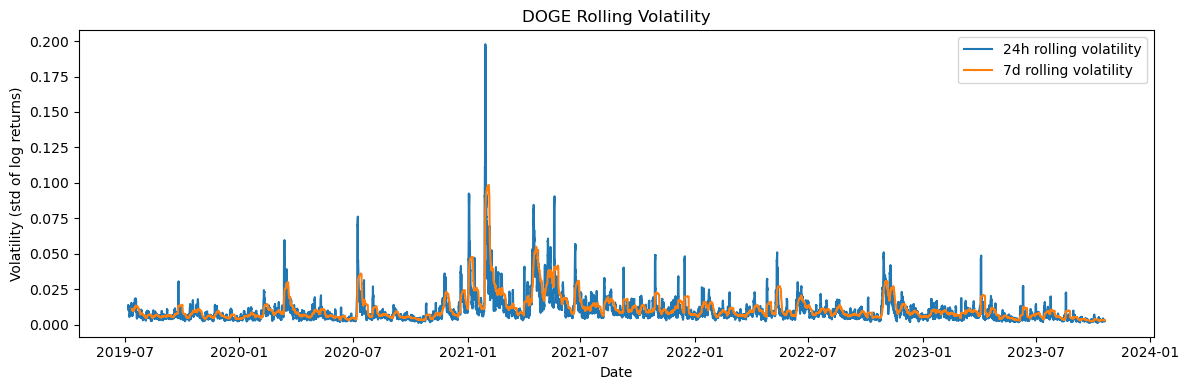


Average log return by hour:


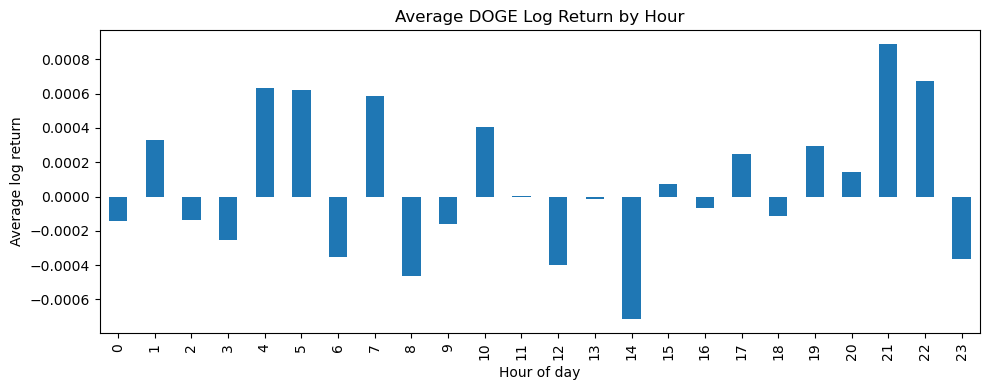


Average log return by weekday:


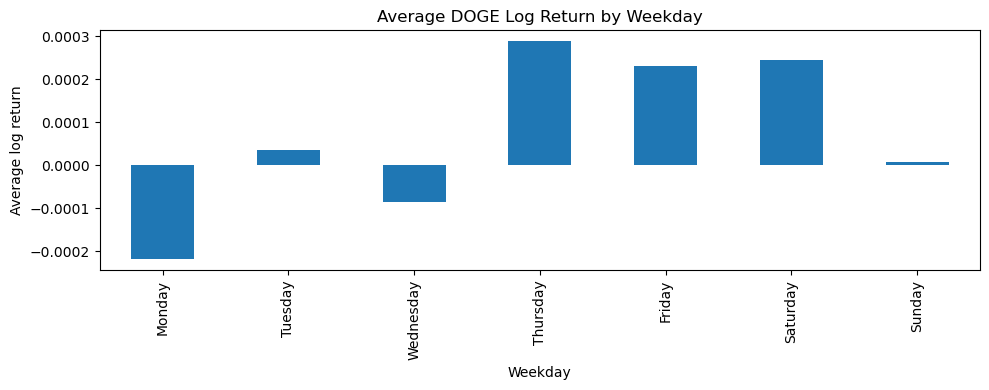


Weekday vs Weekend effects:
             mean       std  count
Weekday  0.000050  0.015065  26833
Weekend  0.000127  0.013498  10742

Correlation between Volume DOGE and tradecount: 0.6291
Correlation between Volume USDT and tradecount: 0.9734


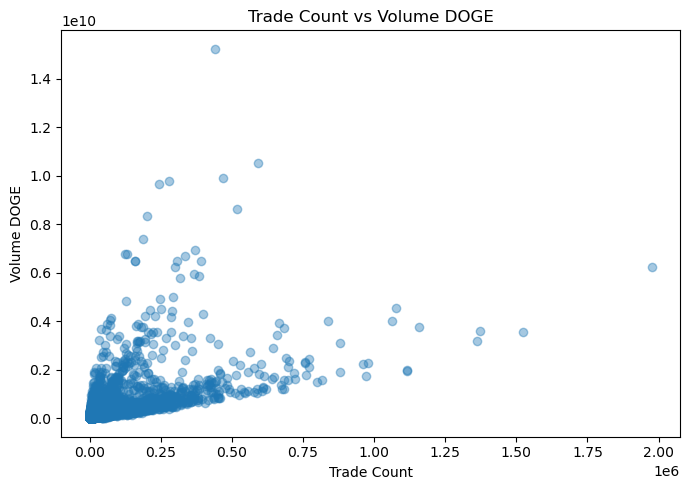

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = binance.copy()

# Parse datetime and sort oldest -> newest
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# --------------------------------------------------
# 1. Log return
# --------------------------------------------------
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

print("Log Return")
print("Convert price levels into returns: log return = log(Close_t / Close_{t-1})")

# Plot log returns
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["log_return"])
plt.title("DOGE Hourly Log Returns")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. Rolling volatility
# --------------------------------------------------
# Common choices:
# 24 hours = 1 day
# 24*7 hours = 1 week
df["rolling_vol_24h"] = df["log_return"].rolling(window=24).std()
df["rolling_vol_7d"] = df["log_return"].rolling(window=24*7).std()

print("Rolling Volatility")
print("Crypto markets exhibit strong volatility dynamics, with periods of calm followed by bursts of high volatility. Rolling volatility helps us visualize these changes over time.")
print("rolling volatility of 24h and 7d (std of log returns)")

# Plot rolling volatility
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["rolling_vol_24h"], label="24h rolling volatility")
plt.plot(df["Date"], df["rolling_vol_7d"], label="7d rolling volatility")
plt.title("DOGE Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (std of log returns)")
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Average return by hour, weekday vs weekend effects
# --------------------------------------------------
df["hour"] = df["Date"].dt.hour
df["weekday_num"] = df["Date"].dt.weekday   # Monday=0, Sunday=6
df["weekday_name"] = df["Date"].dt.day_name()
df["is_weekend"] = df["weekday_num"] >= 5

# Average return by hour
avg_return_by_hour = df.groupby("hour")["log_return"].mean()


print("\nAverage log return by hour:")

plt.figure(figsize=(10, 4))
avg_return_by_hour.plot(kind="bar")
plt.title("Average DOGE Log Return by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Average log return")
plt.tight_layout()
plt.show()

# Average return by weekday
avg_return_by_weekday = df.groupby("weekday_name")["log_return"].mean()

# Reorder weekdays
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
avg_return_by_weekday = avg_return_by_weekday.reindex(weekday_order)

print("\nAverage log return by weekday:")

plt.figure(figsize=(10, 4))
avg_return_by_weekday.plot(kind="bar")
plt.title("Average DOGE Log Return by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average log return")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. Correlation between trading volume and trade count
# --------------------------------------------------
# You can use either DOGE volume or USDT volume
corr_doge = df["Volume DOGE"].corr(df["tradecount"])
corr_usdt = df["Volume USDT"].corr(df["tradecount"])

print(f"\nCorrelation between Volume DOGE and tradecount: {corr_doge:.4f}")
print(f"Correlation between Volume USDT and tradecount: {corr_usdt:.4f}")

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(df["tradecount"], df["Volume DOGE"], alpha=0.4)
plt.title("Trade Count vs Volume DOGE")
plt.xlabel("Trade Count")
plt.ylabel("Volume DOGE")
plt.
plt.tight_layout()
plt.show()

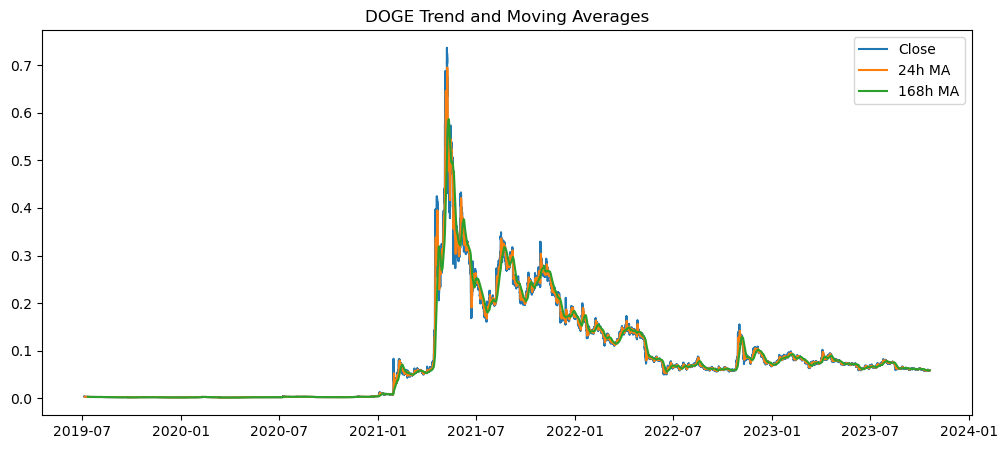

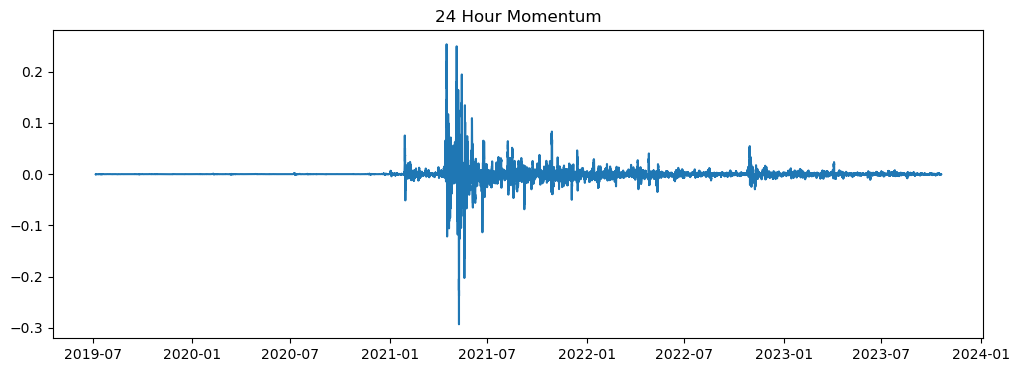

c:\Users\robsl\Downloads\Anaconda\envs\cleanenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\robsl\Downloads\Anaconda\envs\cleanenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\robsl\Downloads\Anaconda\envs\cleanenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\robsl\Downloads\Anaconda\envs\cleanenv\lib\site-packages\statsmodels\t

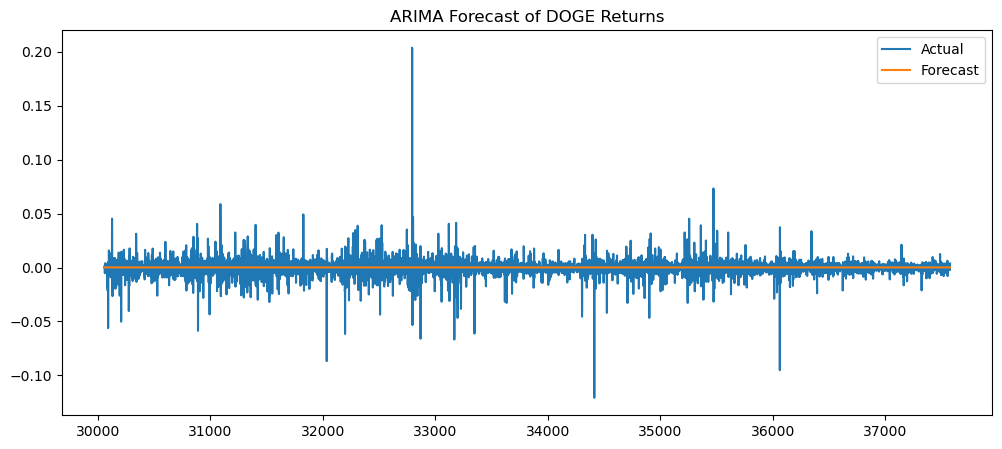

Number of shocks: 376
         vol_before     vol_after
count  3.760000e+02  3.760000e+02
mean   9.739432e+08  1.036659e+09
std    1.401813e+09  1.275524e+09
min    3.494638e+06  5.012487e+06
25%    1.487003e+08  2.620837e+08
50%    4.284048e+08  6.169019e+08
75%    1.129715e+09  1.189811e+09
max    7.601452e+09  7.601452e+09


C:\Users\robsl\AppData\Local\Temp\ipykernel_22804\3442630032.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results["vol_before"], results["vol_after"]],


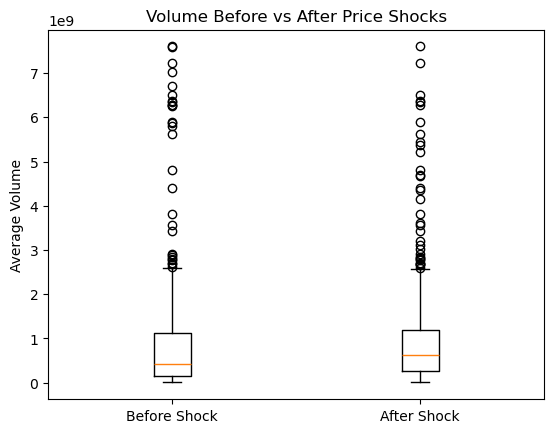

In [9]:
# ==================================================
# 1. TREND & MOMENTUM ANALYSIS
# ==================================================

# Moving averages
df["MA_24"] = df["Close"].rolling(24).mean()        # 1 day
df["MA_168"] = df["Close"].rolling(168).mean()      # 1 week

# Momentum indicator
df["momentum_24h"] = df["Close"] - df["Close"].shift(24)

# Plot trend
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_24"], label="24h MA")
plt.plot(df["Date"], df["MA_168"], label="168h MA")
plt.title("DOGE Trend and Moving Averages")
plt.legend()
plt.show()

# Momentum plot
plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["momentum_24h"])
plt.title("24 Hour Momentum")
plt.show()


# ==================================================
# 2. FORECASTING MODEL (ARIMA)
# ==================================================

# Use returns for stationarity
returns = df["log_return"].dropna()

# Train-test split
train_size = int(len(returns)*0.8)
train = returns[:train_size]
test = returns[train_size:]

# Fit ARIMA
model = ARIMA(train, order=(1,0,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast of DOGE Returns")
plt.legend()
plt.show()


# ==================================================
# 3. PRICE SHOCK DETECTION
# ==================================================

# Define shock threshold (top 1% absolute returns)
threshold = df["log_return"].abs().quantile(0.99)

df["shock"] = df["log_return"].abs() > threshold

shock_indices = df.index[df["shock"]]

print("Number of shocks:", len(shock_indices))


# ==================================================
# 4. VOLUME BEFORE AND AFTER SHOCKS
# ==================================================

window = 12  # hours before and after
results = []

for idx in shock_indices:
    
    if idx-window < 0 or idx+window >= len(df):
        continue
        
    before_vol = df["Volume DOGE"].iloc[idx-window:idx].mean()
    after_vol = df["Volume DOGE"].iloc[idx:idx+window].mean()
    
    results.append([before_vol, after_vol])

results = pd.DataFrame(results, columns=["vol_before","vol_after"])

print(results.describe())

# Plot comparison
plt.boxplot([results["vol_before"], results["vol_after"]],
            labels=["Before Shock","After Shock"])

plt.title("Volume Before vs After Price Shocks")
plt.ylabel("Average Volume")
plt.show()